# 01. Corpora and Declared Schemas

**The question.** What data does this lab stand on — and under what *contract* does each source
enter it? Every experiment downstream (the metrology of 02–03, the noise audit of 04, the
training matrices of 08–11, the 1e7 verdict of 17) consumes corpora through exactly one door:
a **declared schema** that maps a source's real column names onto a fixed vocabulary of
person-record roles, verbatim, with no cleaning. If that door is honest, every later claim
inherits its honesty; if it quietly "fixes" the data, every later claim is about data that does
not exist.

**What this notebook settles.** Four things, each demonstrated live rather than asserted:
(1) what a `DeclaredSchema` is and why `to_canonical` must deliver values *verbatim* — shown on
real rows, including NC-style space padding surviving untouched; (2) the corpus roster — what is
loaded now, what is acquired live below, what is user-side or deferred, with the checksum-gated
refusal shown rather than described; (3) live acquisition of two NC voter-registration snapshots
two years apart — listed, downloaded, parsed, *size-verified against a pre-stated target with the
adjustment rule applied in the open*, and canonicalized — the temporal-diff substrate that feeds
the NSE-01 noise audit and the MET-05 truth-key gate; (4) the two contract artifacts —
`corpus_registry` and `declared_schemas` — whose exact payload shapes notebooks 02–04 (and 18)
consume.

In [1]:
import json
import time

import duckdb
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data import nc
from er_lab.data.loaders import load_bpid, load_fake_1000, load_historical_50k
from er_lab.data.schema import DeclaredSchema
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

Everything size-shaped in this notebook comes from the table below, keyed by tier — one code
path, no forked logic. At `smoke` (this container) and `mid` (the mac) we *request* two NC
counties, Durham (`county_id` 32) and Orange (68); at `target` the same cells parse the
statewide files (`None` = no county filter). The snapshot dates are the same at every tier: two
New-Year's snapshots two years apart, so the same-person diffs span a realistic
re-registration/maintenance window.

Requested is not realized: snapshot row counts are only known after parsing, so each tier also
carries a **row-target band** and section 3 applies a pre-stated adjustment rule if the realized
size falls outside it — measured, decided, and recorded in the open, never silently.

In [3]:
SNAP_WANT = ("20240101", "20260101")  # requested snapshot dates (a, b) — all tiers
COUNTY_REQUEST: dict[str, list[int] | None] = {
    "smoke": [32, 68],  # Durham + Orange
    "mid": [32, 68],
    "target": None,  # statewide — same cells, no county filter
    "analytical": [32, 68],
}
ROW_TARGETS: dict[str, tuple[int, int] | None] = {
    "smoke": (200_000, 500_000),  # per snapshot — big enough to be non-trivial on 4 CPUs
    "mid": (200_000, 1_500_000),  # the mac's ~1e6 tier
    "target": None,  # statewide: whatever NC holds is the point
    "analytical": (200_000, 500_000),
}
REQ_COUNTIES = COUNTY_REQUEST[cfg.run.tier]
REQ_TAG = "all" if REQ_COUNTIES is None else "c" + "-".join(str(c) for c in REQ_COUNTIES)

DATA_ROOT = REPO_ROOT / cfg.paths.data_root
RAW_NC = DATA_ROOT / "raw" / "nc"
PROCESSED = DATA_ROOT / "processed"
SCHEMA_DIR = REPO_ROOT / "configs" / "schemas"
SCHEMA_NAMES = ["historical_50k", "fake_1000", "nc_voter", "onc", "bpid", "ohio"]

print(f"tier={cfg.run.tier}: requested counties={REQ_COUNTIES} (tag '{REQ_TAG}'), "
      f"row target={ROW_TARGETS[cfg.run.tier]}, snapshots {SNAP_WANT}")

tier=smoke: requested counties=[32, 68] (tag 'c32-68'), row target=(200000, 500000), snapshots ('20240101', '20260101')


## 1. What is a declared schema, and why verbatim?

A `DeclaredSchema` is a small YAML file: the source's name, which column is the per-row
`record_id`, which column (if any) is the truth key `entity_id`, and a `roles` map from a fixed
role vocabulary (`given_name`, `family_name`, `dob`, `street`, ...) to the source's actual
columns. `to_canonical` then *relabels and re-types only*: every value crosses the boundary as a
string, exactly as it appeared in the source. No trimming, no case-folding, no date parsing.

Why so strict? Because upstream standardization is an **experimental factor in this lab**
(PRS-01 asks whether parsing/standardization level changes the embeddings-vs-rules ranking), and
you cannot study a treatment your data loader has already silently applied. The dirt *is* the
object of study.

Here is the schema for `historical_50k`, the ~50k-row Wikidata-derived corpus with injected
errors that notebook 00 runs end-to-end:

In [4]:
print((SCHEMA_DIR / "historical_50k.yaml").read_text())

# splink_datasets historical_50k — Wikidata-derived historical persons with injected
# errors; the notebook-00 quickstart corpus. Schema VERIFIED 2026-08-24 with pyarrow from
#   https://raw.githubusercontent.com/moj-analytical-services/splink_datasets/master/data/historical_figures_with_errors_50k.parquet
#   (50578 rows, all string columns): unique_id, cluster, full_name, first_and_surname,
#   first_name, surname, dob, birth_place, postcode_fake, gender, occupation
# Full DOB present. 'cluster' is the ground-truth entity key.
# 'first_and_surname' is a derived concatenation of first_name + surname — not carried.
name: historical_50k
record_id: unique_id
entity_id: cluster
roles:
  full_name: full_name
  given_name: first_name
  family_name: surname
  dob: dob
  city: birth_place # place of birth — this corpus's only locality field
  zip: postcode_fake
  sex: gender
extra_keep: [occupation]



In [5]:
# to_canonical on a 5-row slice: raw source columns in, role-named columns out — values untouched.
hist_schema = DeclaredSchema.from_yaml(SCHEMA_DIR / "historical_50k.yaml")
raw_slice = pd.read_parquet(
    DATA_ROOT / "splink_datasets" / "historical_figures_with_errors_50k.parquet"
).head(5)
print("--- raw source slice ---")
display(raw_slice)
print("--- canonical role frame (relabel + retype only) ---")
display(hist_schema.to_canonical(raw_slice))

--- raw source slice ---


,unique_id,cluster,full_name,first_and_surname,first_name,surname,dob,birth_place,postcode_fake,gender,occupation
0,Q2296770-1,Q2296770,"thomas clifford, 1st baron clifford of chudleigh",thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,male,politician
1,Q2296770-2,Q2296770,thomas of chudleigh,thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,male,politician
2,Q2296770-3,Q2296770,tom 1st baron clifford of chudleigh,tom chudleigh,tom,chudleigh,1630-08-01,devon,tq13 8df,male,politician
3,Q2296770-4,Q2296770,thomas 1st chudleigh,thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8hu,None,politician
4,Q2296770-5,Q2296770,"thomas clifford, 1st baron chudleigh",thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,None,politician


--- canonical role frame (relabel + retype only) ---


,full_name,given_name,family_name,dob,city,zip,sex,record_id,entity_id,source,occupation
0,"thomas clifford, 1st baron clifford of chudleigh",thomas,chudleigh,1630-08-01,devon,tq13 8df,male,Q2296770-1,Q2296770,historical_50k,politician
1,thomas of chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,male,Q2296770-2,Q2296770,historical_50k,politician
2,tom 1st baron clifford of chudleigh,tom,chudleigh,1630-08-01,devon,tq13 8df,male,Q2296770-3,Q2296770,historical_50k,politician
3,thomas 1st chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8hu,<NA>,Q2296770-4,Q2296770,historical_50k,politician
4,"thomas clifford, 1st baron chudleigh",thomas,chudleigh,1630-08-01,devon,tq13 8df,<NA>,Q2296770-5,Q2296770,historical_50k,politician


The second schema is the one this notebook exercises hardest — the NC voter snapshot layout.
Note the *multi-column roles*: `street` is declared as four source columns
(`street_dir`, `street_name`, `street_type_cd`, `street_sufx_cd`) joined in order.

In [6]:
print((SCHEMA_DIR / "nc_voter.yaml").read_text())

# NC voter registration statewide snapshot (VR_SNAPSHOT_YYYYMMDD).
# Column names VERIFIED 2026-08-24 against
#   https://s3.amazonaws.com/dl.ncsbe.gov/data/Snapshots/layout_VR_Snapshot.txt
#   (layout updated 02/15/2021; tab-delimited, header row, UTF-16 LE).
# No full DOB in this source — 'age' only (identifiability hit; MET-06).
# 'ncid' is the statewide pseudo-truth key, usable only if the MET-05 gate passes.
# 'voter_reg_num' is unique per county only — county_id is kept in extra_keep so
# (county_id, voter_reg_num) can disambiguate across counties.
# '#' in name fields and 'xx/xx/xxxx' registr_dt are county-review masking, delivered verbatim.
# Blank fields are SPACE-PADDED in the real files (e.g. half_code=' ', street_dir=' '),
# and multi-column joins keep whitespace-only parts VERBATIM by design — street joins
# to e.g. '  WARD ST  '. The padding is part of the noise under study (PRS-01 owns
# standardization upstream); see _join_verbatim in er_lab/data/schema.py.
name: nc_vot

### The verbatim rule, demonstrated

The real NC files pad blank fields with spaces (`half_code=' '`, `street_dir=' '`). A "helpful"
join would strip that padding — and would thereby erase exactly the raw-form noise PRS-01 needs
intact. The lab's join keeps whitespace-only parts **verbatim**: only true-missing (NA) and the
empty string count as absent.

The two rows below are **constructed** for the demonstration (labeled as such — the same check
is re-run on the real parsed snapshot in section 3): an NC-style row with padded fields, pushed
through `nc_voter`'s `to_canonical`. Watch the padding survive into the joined `street` value —
`repr` makes the spaces visible.

In [7]:
nc_schema = DeclaredSchema.from_yaml(SCHEMA_DIR / "nc_voter.yaml")
_needed = [
    col
    for spec in nc_schema.roles.values()
    for col in ([spec] if isinstance(spec, str) else spec)
] + [nc_schema.record_id, nc_schema.entity_id, *nc_schema.extra_keep]
# CONSTRUCTED demo rows (not data): every needed column present, blanks space-padded NC-style.
demo = pd.DataFrame({col: ["", ""] for col in dict.fromkeys(_needed)})
demo.loc[0, ["first_name", "last_name", "house_num", "half_code"]] = ["MARY", "WARD", "12", " "]
demo.loc[0, ["street_dir", "street_name", "street_type_cd", "street_sufx_cd"]] = [
    " ", "WARD ST       ", " ", " "]
demo.loc[1, ["first_name", "last_name", "house_num"]] = ["JOHN", "OKELLY", "301"]
demo.loc[1, ["street_dir", "street_name", "street_type_cd"]] = ["N ", "CHURCH", "ST"]
demo_canon = nc_schema.to_canonical(demo)
for i in range(len(demo_canon)):
    print(f"row {i}: street       = {demo_canon.loc[i, 'street']!r}")
    print(f"       house_number = {demo_canon.loc[i, 'house_number']!r}")
assert "  " in demo_canon.loc[0, "street"], "padding must survive the join verbatim"
print("\npadding survived to_canonical untouched (assert passed).")

row 0: street       = '  WARD ST           '
       house_number = '12  '
row 1: street       = 'N  CHURCH ST'
       house_number = '301'

padding survived to_canonical untouched (assert passed).


### Adapting the lab = writing one of these YAMLs

This file *is* the adaptation surface. To point the whole pipeline — serialization, training,
blocking, scoring, clustering, evaluation — at your own data, you write one `DeclaredSchema`
YAML mapping your columns onto the role vocabulary and declaring your truth key (or `null` if
you have none). Nothing else in the lab knows your column names. Notebook 18 does exactly this
as a measured exercise (ADP-01: the ONC patient-matching corpus, with a
lines-of-config-changed count), then converts the pipeline from dedup to two-source linkage
(ADP-02). The six schemas shipped in `configs/schemas/` are registered as the
`declared_schemas` artifact at the end of this notebook.

## 2. The corpus roster: what data exists, and how does each source get here?

The repo ships **download scripts and checksums, never data** (`DATA_GOVERNANCE.md`). So every
corpus is in one of four states: *loaded live in this run* (the two splink corpora — small,
openly fetchable, pre-warmed in `data/`), *acquired live below* (NC snapshots), *user-side
download* (BPID and Ohio — their hosts are blocked from this build container, so the loader
refuses with instructions until you place the files), or *fetched by a later notebook* (ONC, in
notebook 18). The row counts below are computed in this run, not quoted.

In [8]:
hist_df, _ = load_historical_50k(DATA_ROOT)
fake_df, _ = load_fake_1000(DATA_ROOT)
roster = pd.DataFrame(
    [
        ("historical_50k", "loaded (this run)", "cluster", len(hist_df),
         "notebook-00 quickstart; CI fixture"),
        ("fake_1000", "loaded (this run)", "cluster", len(fake_df),
         "tiny CI fixture / widget demos"),
        ("nc_voter", "acquired live below", "ncid (gated by MET-05)", None,
         "real-noise audit (NSE-01); temporal eval pairs; truth arms if MET-05 passes"),
        ("bpid", "user-side download (checksum-gated)", "labeled pairs file", None,
         "independent benchmark arm; NSE-02 scores its corruption model"),
        ("ohio", "user-side download (checksum-gated)", "SOS_VOTERID", None,
         "full-DOB collision calibration (SCL-04); ADP-02 NC-OH linkage"),
        ("onc", "fetched in notebook 18 (ADP-01)", "EnterpriseID", None,
         "adaptation walkthrough target; full-DOB identifiability contrast"),
    ],
    columns=["corpus", "status", "truth key", "n_records (this run)", "role in the lab"],
)
display(roster)

[er_lab.data] splink_datasets: splink_datasets (moj-analytical-services): openly downloadable; fake_1000 is synthetic, historical_50k is Wikidata-derived with injected errors; fetched at run time for quickstart and CI fixtures (DATA_GOVERNANCE.md).


,corpus,status,truth key,n_records (this run),role in the lab
0,historical_50k,loaded (this run),cluster,50578.0,notebook-00 quickstart; CI fixture
1,fake_1000,loaded (this run),cluster,1000.0,tiny CI fixture / widget demos
2,nc_voter,acquired live below,ncid (gated by MET-05),NaN,real-noise audit (NSE-01); temporal eval pairs...
3,bpid,user-side download (checksum-gated),labeled pairs file,NaN,independent benchmark arm; NSE-02 scores its c...
4,ohio,user-side download (checksum-gated),SOS_VOTERID,NaN,full-DOB collision calibration (SCL-04); ADP-0...
5,onc,fetched in notebook 18 (ADP-01),EnterpriseID,NaN,adaptation walkthrough target; full-DOB identi...


### The checksum-gated refusal, shown live

BPID's host (zenodo.org) is blocked from this container, so its loader is *supposed to fail*
here — loudly, with instructions, never with silently fabricated data. This is the
never-fabricate rail applied to acquisition. The `FileNotFoundError` below is the demonstration
(on a machine where you have placed the files, this cell would instead load them and verify
their recorded sha256 sidecars):

In [9]:
try:
    load_bpid(DATA_ROOT)
    print("BPID files found locally — loaded and checksum-verified.")
except FileNotFoundError as err:
    print("FileNotFoundError (expected in this container):\n")
    print(err)

[er_lab.data] bpid: BPID (Zenodo record 13932202, Apache-2.0): 1M synthetic PII profiles + 10k labeled pairs; user-side download, checksum-gated; never committed (DATA_GOVERNANCE.md).
FileNotFoundError (expected in this container):

BPID data not found: no csv/parquet files under /home/user/embedding-based-entity-resolution/data/raw/bpid.
zenodo.org is blocked from the build container, so this download is user-side:
  1. Download the BPID archive (Apache-2.0) from https://zenodo.org/records/13932202
  2. Extract its files into /home/user/embedding-based-entity-resolution/data/raw/bpid/
Files must sit directly in that directory or exactly one subdirectory level down
(an extracted archive folder); deeper nesting is not searched.
The loader records a .sha256 sidecar per file on first load and verifies it on
later loads. See DATA_GOVERNANCE.md — the repo ships scripts and checksums, never data.


## 3. Live acquisition: two NC snapshots, two years apart

The NC State Board of Elections publishes statewide voter-registration snapshots keyed by
`ncid`, a statewide identifier that persists across re-registrations. Two snapshots of the same
population at different times give us *same-person pairs whose fields drifted for real* — typos
corrected and introduced, names changed, addresses moved, fields masked — which is what the
NSE-01 audit measures and the calibrated generator (notebook 05) imitates. First question: what
does the archive actually hold today? (A live listing — the count and date range below are
whatever the bucket answers right now.)

In [10]:
snapshots = nc.list_snapshots()
snap_dates = [d for d, _, _ in snapshots]
print(f"snapshots on dl.ncsbe.gov : {len(snapshots)}")
print(f"date range                : {snap_dates[0]} .. {snap_dates[-1]}")
listing_df = pd.DataFrame(
    {"date": snap_dates, "size_mib": [round(size / 2**20, 1) for _, _, size in snapshots]}
)
registry.register(
    "nc_snapshot_listing",
    listing_df,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={"source": "live ListObjectsV2 on dl.ncsbe.gov", "unit": "MiB (compressed zip)"},
)


def choose_snapshot(want: str) -> tuple[str, str]:
    """Requested date if present, else the nearest available (choice recorded)."""
    if want in snap_dates:
        return want, "exact"
    nearest = min(
        snap_dates, key=lambda d: abs((pd.Timestamp(d) - pd.Timestamp(want)).days)
    )
    return nearest, f"nearest available to requested {want}"


SNAP_A, note_a = choose_snapshot(SNAP_WANT[0])
SNAP_B, note_b = choose_snapshot(SNAP_WANT[1])
print(f"snapshot a: {SNAP_A} ({note_a})")
print(f"snapshot b: {SNAP_B} ({note_b})")

[er_lab.data] nc_voter: NC voter registration snapshots (dl.ncsbe.gov): public records under N.C.G.S. 132-1 / 163-82.10; the statutes govern permitted uses; records never redistributed — published artifacts carry aggregates only (DATA_GOVERNANCE.md).


snapshots on dl.ncsbe.gov : 72
date range                : 20051125 .. 20260303
snapshot a: 20240101 (exact)
snapshot b: 20260101 (exact)


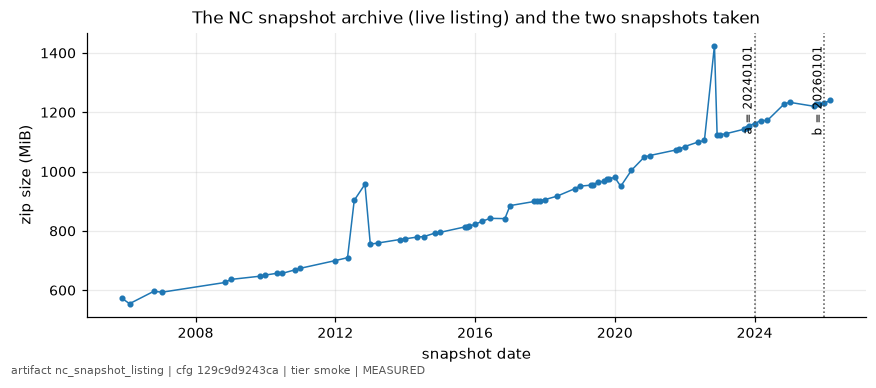

In [11]:
def draw_archive(ax, df, meta):
    dates = pd.to_datetime(df["date"], format="%Y%m%d")
    ax.plot(dates, df["size_mib"], marker="o", markersize=3, linewidth=1)
    for chosen, label in ((SNAP_A, "a"), (SNAP_B, "b")):
        x = pd.to_datetime(chosen, format="%Y%m%d")
        ax.axvline(x, color="0.3", linestyle=":", linewidth=1)
        ax.annotate(f"{label} = {chosen}", (x, float(df["size_mib"].max())),
                    rotation=90, fontsize=8, va="top", ha="right")
    ax.set_xlabel("snapshot date")
    ax.set_ylabel("zip size (MiB)")


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="nc_snapshot_listing",
    draw=draw_archive,
    title="The NC snapshot archive (live listing) and the two snapshots taken",
    figsize=(8.0, 3.5),
)

### The pre-stated expectation

Before any download, the conjecture card states what we expect this acquisition to yield —
Durham + Orange county sizes, near-uniqueness of `ncid` within a snapshot, and substantial
two-year overlap — so the verdict at the end of section 4 is scored against a prediction made
*now*, not fitted afterwards. If the measurement refutes a clause, the verdict box says so and
the recorded adjustment decision (below) documents what changed in response. (At `target` tier
the same cells run statewide; the size clause of this card is scoped to the two-county
smoke/mid configuration it was written for.)

In [12]:
_ = conjecture_card(
    card_id="NB01-NC-ACQUISITION",
    conjecture=(
        "Two county-filtered NC snapshots two years apart form a usable same-person diff "
        "substrate: Durham (32) + Orange (68) are big enough for smoke/mid experiments, ncid "
        "is nearly unique within a snapshot, and most records persist across the two years."
    ),
    pressure=(
        "acquisition choices: snapshots 20240101 vs 20260101; counties [32, 68]; "
        "verbatim parse of the nc_voter.yaml column subset"
    ),
    property=(
        "realized corpus size, within-snapshot ncid uniqueness, and cross-snapshot ncid overlap"
    ),
    metric=(
        "rows per parsed snapshot; duplicated-ncid fraction per side; aligned pairs / "
        "min(rows_a, rows_b)"
    ),
    prediction=(
        "At smoke/mid ([32, 68]): each parsed snapshot lands in 200k-500k rows; the "
        "duplicated-ncid fraction is < 0.5% on each side; aligned same-ncid pairs cover "
        ">= 70% of the smaller snapshot."
    ),
    registry=registry,
)

### Conjecture card `NB01-NC-ACQUISITION`

| | |
|---|---|
| **Conjecture** | Two county-filtered NC snapshots two years apart form a usable same-person diff substrate: Durham (32) + Orange (68) are big enough for smoke/mid experiments, ncid is nearly unique within a snapshot, and most records persist across the two years. |
| **Pressure (dial)** | acquisition choices: snapshots 20240101 vs 20260101; counties [32, 68]; verbatim parse of the nc_voter.yaml column subset |
| **Embedding property** | realized corpus size, within-snapshot ncid uniqueness, and cross-snapshot ncid overlap |
| **System metric** | rows per parsed snapshot; duplicated-ncid fraction per side; aligned pairs / min(rows_a, rows_b) |
| **Pre-registered prediction** | At smoke/mid ([32, 68]): each parsed snapshot lands in 200k-500k rows; the duplicated-ncid fraction is < 0.5% on each side; aligned same-ncid pairs cover >= 70% of the smaller snapshot. |

*Immutable — sha256 `11d8973924ec`; registered before the affected runs, never edited (PLAN §5).*


### Download and parse — idempotent by construction

The zips are >1 GiB each, so **every step below skips itself when its output already exists**:
a complete zip is never re-downloaded (partial downloads resume via HTTP Range), a parsed
parquet with its stats sidecar is never re-parsed, and canonical/aligned parquets are rebuilt
only when missing or older than their inputs. A cold run of this section costs tens of minutes
(dominated by download + the streamed UTF-16 parse); a warm re-run costs seconds.

The parse itself streams the ~4 GB inner TSV in 50k-row chunks (never held in memory), keeps
every value as a verbatim string, and refuses to absorb malformed rows silently: rows *shorter*
than the header are padded and counted, rows *longer* than the header are quarantined into a
`.ragged.json` sidecar with their row numbers. Those counts are real parse facts — they appear
in the stats table below and feed the layout-consistency question notebook 04 cares about.
We parse only the columns the `nc_voter` schema needs (its roles + ids + `extra_keep`, which
includes `county_id`).

In [13]:
PARSE_COLUMNS = list(dict.fromkeys(_needed))
print(f"{len(PARSE_COLUMNS)} columns parsed: {PARSE_COLUMNS}")


def ensure_snapshot(date: str) -> dict:
    """Download + county-parse one snapshot (skips work already done); returns parse stats."""
    parsed = RAW_NC / f"nc_parsed_{date}_{REQ_TAG}.parquet"
    stats_path = parsed.with_name(parsed.name + ".stats.json")
    if parsed.exists() and stats_path.exists():
        print(f"[idempotent] {parsed.name} exists — download+parse skipped")
    else:
        t0 = time.time()
        zip_path = nc.download_snapshot(date, RAW_NC)
        print(f"downloaded {zip_path.name} ({zip_path.stat().st_size >> 20} MiB) "
              f"in {time.time() - t0:.0f}s")
        t0 = time.time()
        nc.parse_snapshot(zip_path, parsed, counties=REQ_COUNTIES, columns=PARSE_COLUMNS)
        print(f"parsed -> {parsed.name} in {time.time() - t0:.0f}s")
    return json.loads(stats_path.read_text())

27 columns parsed: ['first_name', 'midl_name', 'last_name', 'name_sufx_cd', 'age', 'sex_code', 'race_code', 'ethnic_code', 'house_num', 'half_code', 'street_dir', 'street_name', 'street_type_cd', 'street_sufx_cd', 'unit_num', 'res_city_desc', 'state_cd', 'zip_code', 'area_cd', 'phone_num', 'county_desc', 'snapshot_dt', 'voter_reg_num', 'ncid', 'county_id', 'status_cd', 'registr_dt']


In [14]:
stats_a = ensure_snapshot(SNAP_A)
print(f"{SNAP_A}: {stats_a}")

[idempotent] nc_parsed_20240101_c32-68.parquet exists — download+parse skipped
20240101: {'rows': 1115657, 'padded_short_rows': 0, 'ragged_long_rows': 0}


In [15]:
stats_b = ensure_snapshot(SNAP_B)
print(f"{SNAP_B}: {stats_b}")

[idempotent] nc_parsed_20260101_c32-68.parquet exists — download+parse skipped
20260101: {'rows': 1195912, 'padded_short_rows': 0, 'ragged_long_rows': 0}


### Did the parse land where we aimed? Verify, adjust, record

The stats sidecars above are the parse's own accounting — rows written after the county filter,
short rows padded, long rows quarantined. Now the size verification. A registered-voter count
is *not* a snapshot row count: NC snapshots retain the county's full registration history, so
every row with `status_cd` R (removed), I (inactive), D (denied) or S (surrendered) is still
there next to the active ones — by design, verbatim, because overlays and stale registrations
are part of the noise under study. A county's snapshot rows can therefore be several times its
active-voter count, and the only honest way to size the corpus is to measure it.

**The pre-stated adjustment rule** (coded below *before* the realized numbers are seen): if the
larger snapshot's realized total falls outside this tier's row-target band, drop the
largest-realized county and re-check, until the total fits or one county remains; the trimmed
subset is derived from the already-parsed superset (same rows, no re-scan), and the decision —
either way — is recorded here and in the `corpus_registry` meta.

In [16]:
req_parsed = {d: RAW_NC / f"nc_parsed_{d}_{REQ_TAG}.parquet" for d in (SNAP_A, SNAP_B)}
parse_stats = pd.DataFrame(
    [{"snapshot": d, **s} for d, s in ((SNAP_A, stats_a), (SNAP_B, stats_b))]
).set_index("snapshot")
print(f"parse stats sidecars (requested county set {REQ_COUNTIES}):")
display(parse_stats)

con = duckdb.connect()
by_county = pd.DataFrame(
    {
        d: con.execute(
            "SELECT TRY_CAST(county_id AS INTEGER) AS county, "
            f"count(*) AS n FROM read_parquet('{p.as_posix()}') GROUP BY 1 ORDER BY 1"
        )
        .df()
        .set_index("county")["n"]
        for d, p in req_parsed.items()
    }
).fillna(0).astype(int)
status_mix = (
    con.execute(
        "SELECT county_desc, status_cd, count(*) AS n "
        f"FROM read_parquet('{req_parsed[SNAP_A].as_posix()}') GROUP BY 1, 2"
    )
    .df()
    .pivot(index="county_desc", columns="status_cd", values="n")
    .fillna(0)
    .astype(int)
)
con.close()
print("realized rows per county:")
display(by_county)
print(f"status composition, snapshot {SNAP_A} (A=active, I=inactive, D=denied, R=removed, "
      "S=surrendered) — why row counts dwarf active-voter counts:")
display(status_mix)

parse stats sidecars (requested county set [32, 68]):


,rows,padded_short_rows,ragged_long_rows
snapshot,,,
20240101,1115657,0,0
20260101,1195912,0,0


realized rows per county:


,20240101,20260101
county,,
32,692522,748462
68,423135,447450


status composition, snapshot 20240101 (A=active, I=inactive, D=denied, R=removed, S=surrendered) — why row counts dwarf active-voter counts:


status_cd,A,D,I,R,S
county_desc,,,,,
DURHAM,194988,10102,38670,448139,623
ORANGE,94519,3678,13810,310644,484


In [17]:
if REQ_COUNTIES is None:
    FINAL_COUNTIES = None
    decision = "statewide parse (no county filter): no row-target band applies at this tier."
else:
    lo, hi = ROW_TARGETS[cfg.run.tier]
    keep = [int(c) for c in REQ_COUNTIES]
    dropped: list[int] = []
    while len(keep) > 1 and int(by_county.loc[keep].sum().max()) > hi:
        biggest = int(by_county.loc[keep].max(axis=1).idxmax())
        keep.remove(biggest)
        dropped.append(biggest)
    FINAL_COUNTIES = keep
    worst = int(by_county.loc[keep].sum().max())
    if not dropped and lo <= worst <= hi:
        decision = (f"requested counties {REQ_COUNTIES} realized "
                    f"{by_county.sum().to_dict()} rows — inside the {lo}-{hi} band; kept.")
    elif dropped:
        decision = (f"requested counties {REQ_COUNTIES} realized "
                    f"{by_county.sum().to_dict()} rows — over the {lo}-{hi} band "
                    f"(snapshots retain removed/inactive registrations). Adjustment rule "
                    f"dropped {dropped} (largest first); kept {keep} with worst-case "
                    f"{worst} rows/snapshot.")
    else:
        decision = (f"counties {keep} realized worst-case {worst} rows/snapshot, outside "
                    f"the {lo}-{hi} band but not adjustable further; kept — revisit the "
                    "county set before the next tier and record the change in PLAN.md.")
TAG = "all" if FINAL_COUNTIES is None else "c" + "-".join(str(c) for c in FINAL_COUNTIES)
print(f"decision: {decision}")
print(f"final county set: {FINAL_COUNTIES} (tag '{TAG}')")

decision: requested counties [32, 68] realized {'20240101': 1115657, '20260101': 1195912} rows — over the 200000-500000 band (snapshots retain removed/inactive registrations). Adjustment rule dropped [32] (largest first); kept [68] with worst-case 447450 rows/snapshot.
final county set: [68] (tag 'c68')


In [18]:
def ensure_final_parquet(date: str) -> dict:
    """Derive the final-county parquet from the requested-set parse (no re-scan)."""
    src = req_parsed[date]
    if TAG == REQ_TAG:
        return json.loads((src.parent / (src.name + ".stats.json")).read_text())
    out = RAW_NC / f"nc_parsed_{date}_{TAG}.parquet"
    stats_path = out.with_name(out.name + ".stats.json")
    if out.exists() and stats_path.exists() and out.stat().st_mtime >= src.stat().st_mtime:
        print(f"[idempotent] {out.name} is up to date — derivation skipped")
    else:
        wanted = ", ".join(str(c) for c in FINAL_COUNTIES)
        out.unlink(missing_ok=True)  # a stale derivation is replaced, never appended to
        con = duckdb.connect()
        n = con.execute(
            f"COPY (SELECT * FROM read_parquet('{src.as_posix()}') "
            f"WHERE TRY_CAST(county_id AS INTEGER) IN ({wanted})) "
            f"TO '{out.as_posix()}' (FORMAT parquet)"
        ).fetchone()[0]
        con.close()
        parent = json.loads((src.parent / (src.name + ".stats.json")).read_text())
        stats_path.write_text(json.dumps(
            {"rows": n,
             "padded_short_rows": parent["padded_short_rows"],  # whole-scan facts, inherited
             "ragged_long_rows": parent["ragged_long_rows"],
             "derived_from": src.name}) + "\n")
        print(f"derived {out.name}: {n} rows from {src.name}")
    return json.loads(stats_path.read_text())


final_stats = {d: ensure_final_parquet(d) for d in (SNAP_A, SNAP_B)}
print(json.dumps(final_stats, indent=2))

[idempotent] nc_parsed_20240101_c68.parquet is up to date — derivation skipped
[idempotent] nc_parsed_20260101_c68.parquet is up to date — derivation skipped
{
  "20240101": {
    "rows": 423135,
    "padded_short_rows": 0,
    "ragged_long_rows": 0,
    "derived_from": "nc_parsed_20240101_c32-68.parquet"
  },
  "20260101": {
    "rows": 447450,
    "padded_short_rows": 0,
    "ragged_long_rows": 0,
    "derived_from": "nc_parsed_20260101_c32-68.parquet"
  }
}


### Canonicalization: parsed columns -> role frame on disk

`to_canonical` relabels each parsed snapshot into the role vocabulary and writes
`data/processed/nc_snap_<date>.parquet`. One extra column rides along: `ncid` (a copy of
`entity_id`) — `align_pair` joins on it by name, and keeping it spares every downstream
consumer a rename. This is also where we re-run the verbatim check from section 1 on *real*
rows: space-padded street parts must arrive in the canonical frame with their padding intact.

In [19]:
def ensure_canonical(date: str) -> tuple:
    """Canonicalize one parsed snapshot to data/processed (skips when up to date)."""
    parsed = RAW_NC / f"nc_parsed_{date}_{TAG}.parquet"
    out = PROCESSED / f"nc_snap_{date}.parquet"
    if out.exists() and out.stat().st_mtime >= parsed.stat().st_mtime:
        print(f"[idempotent] {out.name} is up to date — canonicalization skipped")
    else:
        t0 = time.time()
        canon = nc_schema.to_canonical(pd.read_parquet(parsed))
        canon["ncid"] = canon["entity_id"]  # keep the statewide join key under its own name
        out.parent.mkdir(parents=True, exist_ok=True)
        canon.to_parquet(out)
        print(f"canonicalized {len(canon)} rows -> {out.name} in {time.time() - t0:.0f}s")
    return out, pq.read_metadata(out).num_rows


canon_path_a, n_canon_a = ensure_canonical(SNAP_A)
canon_path_b, n_canon_b = ensure_canonical(SNAP_B)
print(f"{SNAP_A}: {n_canon_a} canonical rows | {SNAP_B}: {n_canon_b} canonical rows")

[idempotent] nc_snap_20240101.parquet is up to date — canonicalization skipped
[idempotent] nc_snap_20260101.parquet is up to date — canonicalization skipped
20240101: 423135 canonical rows | 20260101: 447450 canonical rows


In [20]:
# The verbatim check, on real data this time: how many street values kept raw space padding?
# Real street text is masked for display per DATA_GOVERNANCE.md (aggregates only in shipped
# outputs): every non-space character becomes 'x', every space stays verbatim — the padding
# is the evidence, and it survives the masking untouched.


def pad_shape(val: str) -> str:
    """Padding-only view of a real value: non-space chars -> 'x', spaces verbatim."""
    return "".join(" " if ch == " " else "x" for ch in str(val))


street_a = pd.read_parquet(canon_path_a, columns=["street"])["street"]
padded = street_a[
    street_a.str.startswith(" ", na=False) | street_a.str.contains("  ", na=False)
]
frac = len(padded) / len(street_a)
print(f"{len(padded)} of {len(street_a)} street values ({frac:.1%}) carry leading/embedded "
      "padding, verbatim (values masked, spacing real):")
for val in padded.head(3):
    print(f"  {pad_shape(val)!r}")
if len(padded) == 0:
    print("  (none found in this snapshot - the padding convention did not occur here)")

423134 of 423135 street values (100.0%) carry leading/embedded padding, verbatim (values masked, spacing real):
  '  xxxxxxx xx  '
  '  xxxxxxx xx  '
  'x xxxxxxxx xx  '


In [21]:
# A 5-row look at the canonical frame itself — masked for display in the same style
# notebook 03 uses (initials, truncated ids, padding-only street), per DATA_GOVERNANCE.md;
# the frame on disk holds the verbatim values.
_prev = pd.read_parquet(
    canon_path_a,
    columns=["record_id", "entity_id", "given_name", "family_name", "age",
             "street", "city", "county", "snapshot_date"],
).head(5)


def _initial(s: pd.Series) -> pd.Series:
    return s.fillna("").astype(str).str.strip().str.slice(0, 1).replace("", "-") + "."


display(pd.DataFrame({
    "record_id": _prev["record_id"].astype(str).str.slice(0, 4) + "…",
    "ncid": _prev["entity_id"].astype(str).str.slice(0, 4) + "…",
    "name": _initial(_prev["given_name"]) + " " + _initial(_prev["family_name"]),
    "age": _prev["age"].astype(str).str.strip(),
    "street (padding only)": _prev["street"].map(pad_shape),
    "city": _prev["city"].astype(str).str.strip(),
    "county": _prev["county"].astype(str).str.strip(),
    "snapshot_date": _prev["snapshot_date"].astype(str).str.strip(),
}))

,record_id,ncid,name,age,street (padding only),city,county,snapshot_date
0,0000…,EF18…,M. J.,28,xxxxxxx xx,CHAPEL HILL,ORANGE,2024-01-01
1,0000…,DE28…,D. O.,74,xxxxxxx xx,CHAPEL HILL,ORANGE,2024-01-01
2,0000…,AA12…,S. R.,46,x xxxxxxxx xx,MEBANE,ORANGE,2024-01-01
3,0000…,DE30…,J. S.,27,xxxxxxxxxxxx xx,CHAPEL HILL,ORANGE,2024-01-01
4,0000…,BH16…,E. S.,35,xxxxxxxx xx,CARRBORO,ORANGE,2024-01-01


## 4. Same-person pairs: aligning the two snapshots on `ncid`

`align_pair` inner-joins the two canonical snapshots on `ncid`, producing one row per person
present in both — every role twice (`given_name_a` / `given_name_b`, ...). These are the
same-person temporal diffs the NSE-01 audit classifies in notebook 04.

One policy matters enough to surface here: an `ncid` that appears **more than once within
either snapshot is excluded entirely** (all its rows, both sides). Do not expect this count to
be cosmetic: because a snapshot retains the registration *history*, a person who was removed
and later re-registered can sit in the same snapshot twice — an old `R` row and a current `A`
row sharing one ncid — alongside genuine overlays and data errors. `align_pair` cannot know
which row is "the" record, and cross-product join rows would be spurious "same-person" pairs
biasing the measured noise prevalence, so it excludes the ncid and reports how many. That
count is exactly what MET-05 (the ncid-stability gate, notebook 03) needs — so it is displayed
here and carried into the `corpus_registry` artifact. The duplicated-ncid *share* below is
computed over **distinct ncids** per snapshot — the same denominator MET-05's G1 clause uses in
notebook 03 — so the two notebooks print the same number for the same concept. (An earlier run
of this notebook divided the count by *rows*, a ncids-per-row hybrid; the denominator is
corrected here.) Note one reading caveat for the overlap
number: the
county filter means a person who *moved out of the kept counties* between the snapshots leaves
the join even though their ncid persists statewide — at smoke/mid the overlap is a
within-counties lower bound.

In [22]:
ALIGNED = PROCESSED / f"nc_aligned_{SNAP_A}_{SNAP_B}.parquet"
align_sidecar = ALIGNED.with_name(ALIGNED.name + ".stats.json")
inputs_mtime = max(canon_path_a.stat().st_mtime, canon_path_b.stat().st_mtime)
if ALIGNED.exists() and align_sidecar.exists() and ALIGNED.stat().st_mtime >= inputs_mtime:
    print(f"[idempotent] {ALIGNED.name} is up to date — align skipped")
    align_stats = json.loads(align_sidecar.read_text())
else:
    t0 = time.time()
    ALIGNED.unlink(missing_ok=True)  # a stale join is replaced, never appended to
    _, align_stats = nc.align_pair(
        canon_path_a, canon_path_b, out_parquet=ALIGNED, return_stats=True
    )
    align_sidecar.write_text(json.dumps(align_stats) + "\n")
    print(f"aligned -> {ALIGNED.name} in {time.time() - t0:.0f}s")

n_ncids_a = pd.read_parquet(canon_path_a, columns=["ncid"])["ncid"].nunique()
n_ncids_b = pd.read_parquet(canon_path_b, columns=["ncid"])["ncid"].nunique()
dup_frac_a = align_stats["dup_ncids_a"] / n_ncids_a
dup_frac_b = align_stats["dup_ncids_b"] / n_ncids_b
overlap = align_stats["pairs"] / min(n_canon_a, n_canon_b)
print(f"pairs                : {align_stats['pairs']}")
print(f"dup ncids excluded a : {align_stats['dup_ncids_a']} of {n_ncids_a} distinct ncids "
      f"({dup_frac_a:.4%})")
print(f"dup ncids excluded b : {align_stats['dup_ncids_b']} of {n_ncids_b} distinct ncids "
      f"({dup_frac_b:.4%})")
print(f"overlap              : {overlap:.1%} of the smaller snapshot")

[idempotent] nc_aligned_20240101_20260101.parquet is up to date — align skipped


pairs                : 391257
dup ncids excluded a : 13226 of 407815 distinct ncids (3.2431%)
dup ncids excluded b : 15775 of 429139 distinct ncids (3.6760%)
overlap              : 92.5% of the smaller snapshot


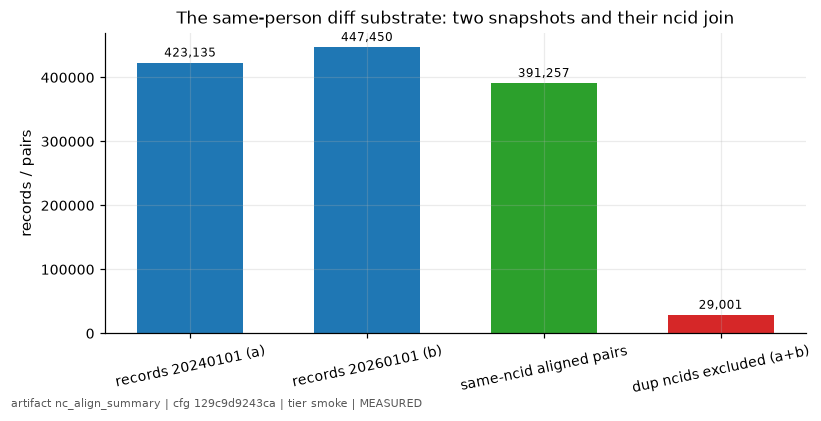

In [23]:
align_summary = pd.DataFrame(
    {
        "quantity": [
            f"records {SNAP_A} (a)",
            f"records {SNAP_B} (b)",
            "same-ncid aligned pairs",
            "dup ncids excluded (a+b)",
        ],
        "count": [
            n_canon_a,
            n_canon_b,
            align_stats["pairs"],
            align_stats["dup_ncids_a"] + align_stats["dup_ncids_b"],
        ],
    }
)
registry.register(
    "nc_align_summary",
    align_summary,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={"counties": FINAL_COUNTIES, "snapshots": [SNAP_A, SNAP_B]},
)


def draw_align(ax, df, meta):
    bars = ax.bar(df["quantity"], df["count"], color=["C0", "C0", "C2", "C3"], width=0.6)
    ax.bar_label(bars, fmt="{:,.0f}", fontsize=8, padding=2)
    ax.set_ylabel("records / pairs")
    ax.tick_params(axis="x", labelrotation=12)


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="nc_align_summary",
    draw=draw_align,
    title="The same-person diff substrate: two snapshots and their ncid join",
    figsize=(7.5, 3.8),
)

### Verdict on the acquisition conjecture

The card predicted three things for the requested `[32, 68]` configuration; each clause is
scored against numbers computed above. The size clause is scored on the **requested-set parse**
(what the card was about), the uniqueness and overlap clauses on the final substrate.

In [24]:
size_clause_applies = REQ_COUNTIES == [32, 68]
req_sizes_ok = bool(parse_stats["rows"].between(200_000, 500_000).all())
checks = {
    "requested-set sizes in 200k-500k": req_sizes_ok if size_clause_applies else True,
    "dup-ncid fraction < 0.5% each side": dup_frac_a < 0.005 and dup_frac_b < 0.005,
    "overlap >= 70% of smaller snapshot": overlap >= 0.70,
}
outcome = "CONFIRMED" if all(checks.values()) else "REFUTED"
evidence = (
    f"requested-set rows: {parse_stats['rows'].to_dict()}; final counties {FINAL_COUNTIES} "
    f"-> rows {n_canon_a} ({SNAP_A}) / {n_canon_b} ({SNAP_B}); duplicated-ncid fraction "
    f"{dup_frac_a:.4%} / {dup_frac_b:.4%} (dup ncids / distinct ncids per side, MET-05's G1 "
    f"denominator); aligned pairs "
    f"{align_stats['pairs']} = {overlap:.1%} of the smaller snapshot. Checks: {checks}. "
    f"Recorded decision: {decision}"
    + ("" if size_clause_applies else " Size clause not scored (statewide tier).")
)
_ = verdict_box("NB01-NC-ACQUISITION", outcome=outcome, evidence=evidence, registry=registry)

> ### VERDICT: REFUTED — card `NB01-NC-ACQUISITION`
>
> **Conjecture** Two county-filtered NC snapshots two years apart form a usable same-person diff substrate: Durham (32) + Orange (68) are big enough for smoke/mid experiments, ncid is nearly unique within a snapshot, and most records persist across the two years.
>
> **Prediction** At smoke/mid ([32, 68]): each parsed snapshot lands in 200k-500k rows; the duplicated-ncid fraction is < 0.5% on each side; aligned same-ncid pairs cover >= 70% of the smaller snapshot.
>
> **Evidence** requested-set rows: {'20240101': 1115657, '20260101': 1195912}; final counties [68] -> rows 423135 (20240101) / 447450 (20260101); duplicated-ncid fraction 3.2431% / 3.6760% (dup ncids / distinct ncids per side, MET-05's G1 denominator); aligned pairs 391257 = 92.5% of the smaller snapshot. Checks: {'requested-set sizes in 200k-500k': False, 'dup-ncid fraction < 0.5% each side': False, 'overlap >= 70% of smaller snapshot': True}. Recorded decision: requested counties [32, 68] realized {'20240101': 1115657, '20260101': 1195912} rows — over the 200000-500000 band (snapshots retain removed/inactive registrations). Adjustment rule dropped [32] (largest first); kept [68] with worst-case 447450 rows/snapshot.


## 5. The contract artifacts

Everything downstream reaches this notebook's work through two registered artifacts, and their
payload shapes are a **contract** with notebooks 02–04 (and 18):

- `corpus_registry` — where each loaded corpus lives (paths relative to the repo root), how
  many records it has in this run, and which schema governs it; plus the NC snapshot pair with
  its counties, aligned-pairs path, and the duplicate-ncid exclusion stats MET-05 consumes.
- `declared_schemas` — for each shipped schema: its YAML path, its role map, and its truth key
  (or `None`). Notebook 18's adaptation exercise starts from this artifact.

In [25]:
def rel(path) -> str:
    return str(path.relative_to(REPO_ROOT))


corpus_registry = {
    "historical_50k": {
        "path": rel(DATA_ROOT / "splink_datasets" / "historical_figures_with_errors_50k.parquet"),
        "n_records": len(hist_df),
        "schema": rel(SCHEMA_DIR / "historical_50k.yaml"),
    },
    "fake_1000": {
        "path": rel(DATA_ROOT / "splink_datasets" / "fake_1000.csv"),
        "n_records": len(fake_df),
        "schema": rel(SCHEMA_DIR / "fake_1000.yaml"),
    },
    "nc_snapshots": {
        "a": {"date": SNAP_A, "path": rel(canon_path_a), "n_records": int(n_canon_a)},
        "b": {"date": SNAP_B, "path": rel(canon_path_b), "n_records": int(n_canon_b)},
        "counties": FINAL_COUNTIES,
        "aligned_path": rel(ALIGNED),
        "align_stats": {k: int(v) for k, v in align_stats.items()},
    },
}
registry.register(
    "corpus_registry",
    corpus_registry,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "requested_snapshots": list(SNAP_WANT),
        "snapshot_choice": {"a": note_a, "b": note_b},
        "requested_counties": REQ_COUNTIES,
        "row_target": ROW_TARGETS[cfg.run.tier],
        "realized_rows_by_county": {
            str(c): {d: int(n) for d, n in row.items()} for c, row in by_county.iterrows()
        },
        "county_decision": decision,
        "parse_stats_requested": {SNAP_A: stats_a, SNAP_B: stats_b},
        "parse_stats_final": final_stats,
        "parse_columns": PARSE_COLUMNS,
        "verdict": outcome,
    },
)
print(json.dumps(corpus_registry, indent=2))

{
  "historical_50k": {
    "path": "data/splink_datasets/historical_figures_with_errors_50k.parquet",
    "n_records": 50578,
    "schema": "configs/schemas/historical_50k.yaml"
  },
  "fake_1000": {
    "path": "data/splink_datasets/fake_1000.csv",
    "n_records": 1000,
    "schema": "configs/schemas/fake_1000.yaml"
  },
  "nc_snapshots": {
    "a": {
      "date": "20240101",
      "path": "data/processed/nc_snap_20240101.parquet",
      "n_records": 423135
    },
    "b": {
      "date": "20260101",
      "path": "data/processed/nc_snap_20260101.parquet",
      "n_records": 447450
    },
    "counties": [
      68
    ],
    "aligned_path": "data/processed/nc_aligned_20240101_20260101.parquet",
    "align_stats": {
      "dup_ncids_a": 13226,
      "dup_ncids_b": 15775,
      "pairs": 391257
    }
  }
}


In [26]:
declared_schemas = {}
for name in SCHEMA_NAMES:
    schema = DeclaredSchema.from_yaml(SCHEMA_DIR / f"{name}.yaml")
    declared_schemas[name] = {
        "yaml": rel(SCHEMA_DIR / f"{name}.yaml"),
        "roles": dict(schema.roles),
        "entity_id": schema.entity_id,
    }
registry.register(
    "declared_schemas",
    declared_schemas,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={"record_ids": {n: DeclaredSchema.from_yaml(SCHEMA_DIR / f"{n}.yaml").record_id
                         for n in SCHEMA_NAMES}},
)
display(
    pd.DataFrame(
        [
            {
                "schema": name,
                "entity_id": spec["entity_id"],
                "n_roles": len(spec["roles"]),
                "roles": ", ".join(spec["roles"]),
            }
            for name, spec in declared_schemas.items()
        ]
    ).set_index("schema")
)
print(f"\nnotebook wall-clock so far: {time.time() - NB_T0:.0f}s")

,entity_id,n_roles,roles
schema,,,
historical_50k,cluster,7,"full_name, given_name, family_name, dob, city,..."
fake_1000,cluster,5,"given_name, family_name, dob, city, email"
nc_voter,ncid,17,"given_name, middle_name, family_name, name_suf..."
onc,EnterpriseID,13,"given_name, middle_name, family_name, name_suf..."
bpid,None,5,"full_name, email, phone, street_address, dob"
ohio,SOS_VOTERID,9,"given_name, middle_name, family_name, name_suf..."



notebook wall-clock so far: 8s


## What we now know

- **The adaptation contract is real and verbatim.** A `DeclaredSchema` maps columns to roles
  and changes nothing else — NC-style space padding survives `to_canonical` untouched, on
  constructed rows and on the real parsed snapshot alike. Adapting the lab to new data means
  writing one YAML (notebook 18 measures exactly how much).
- **The corpus roster is explicit about provenance.** Two corpora load live from the pre-warmed
  cache, the NC snapshots are acquired live and idempotently, BPID/Ohio refuse loudly with
  user-side instructions (shown, not described), and ONC waits for notebook 18.
- **Snapshot rows are not registered voters.** NC snapshots retain the full registration
  history — removed/inactive/denied rows sit beside active ones — so realized sizes were
  measured, checked against the tier's pre-stated row-target band, and the county set was
  adjusted by the pre-stated rule with the decision recorded (see the verdict box: the size
  clause of the acquisition conjecture is scored against what actually happened).
- **The NC diff substrate exists on disk.** Two snapshots two years apart, county-filtered and
  canonicalized, plus their same-ncid aligned pairs — with parse-anomaly counts (padded/ragged
  rows) and duplicate-ncid exclusion stats measured and recorded.

## What this changes downstream

- Notebook 02 (metrology) and every later notebook load corpora through `corpus_registry` —
  nothing downstream hardcodes a path or a row count.
- Notebook 03 (MET-05/MET-06) starts from `align_stats` — the duplicate-ncid exclusion counts
  here are its first evidence about ncid's fitness as pseudo-truth.
- Notebook 04 (NSE-01) classifies the field diffs in the aligned parquet registered here.
- Notebook 18 (ADP-01/02) starts its adaptation from `declared_schemas`.

**Artifacts registered** (exact names): `corpus_registry`, `declared_schemas` — plus the
supporting `nc_snapshot_listing` and `nc_align_summary` figure tables and the immutable
conjecture card `card_NB01-NC-ACQUISITION`.